In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("Dataset.csv")

In [5]:
print(df.head())

                                        product_name  product_price  Rate  \
0  Candes 12 L Room/Personal Air Cooler??????(Whi...           3999     5   
1  Candes 12 L Room/Personal Air Cooler??????(Whi...           3999     5   
2  Candes 12 L Room/Personal Air Cooler??????(Whi...           3999     3   
3  Candes 12 L Room/Personal Air Cooler??????(Whi...           3999     1   
4  Candes 12 L Room/Personal Air Cooler??????(Whi...           3999     3   

            Review                                            Summary  \
0           super!  great cooler excellent air flow and for this p...   
1          awesome              best budget 2 fit cooler nice cooling   
2             fair  the quality is good but the power of air is de...   
3  useless product                  very bad product its a only a fan   
4             fair                                      ok ok product   

  Sentiment  
0  positive  
1  positive  
2  positive  
3  negative  
4   neutral  


In [6]:
print(df.shape)

(308, 6)


In [7]:
print(df.columns)

Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_name   308 non-null    object
 1   product_price  308 non-null    int64 
 2   Rate           308 non-null    int64 
 3   Review         308 non-null    object
 4   Summary        308 non-null    object
 5   Sentiment      308 non-null    object
dtypes: int64(2), object(4)
memory usage: 14.6+ KB
None


In [9]:
print(df.isnull().sum())
print(df.duplicated().sum())

product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
dtype: int64
4


In [10]:
df = df.drop_duplicates()
df = df.dropna(subset=["Review"])

In [11]:
df["Cleaned_Review"] = df["Review"].str.lower()

In [12]:
print(df[["product_price", "Rate"]].mean())

product_price    7952.947368
Rate                4.023026
dtype: float64


In [13]:
print(df[["product_price", "Rate"]].median())

product_price    7999.0
Rate                5.0
dtype: float64


In [15]:
print(df[["product_price", "Rate"]].mode())

   product_price  Rate
0           7999     5


In [16]:
print(df[["product_price", "Rate"]].min())

product_price    3999
Rate                1
dtype: int64


In [17]:
print(df[["product_price", "Rate"]].max())

product_price    8999
Rate                5
dtype: int64


In [18]:
print(df[["product_price", "Rate"]].var())

product_price    611733.541775
Rate                  1.850953
dtype: float64


In [19]:
print(df[["product_price", "Rate"]].std())

product_price    782.133967
Rate               1.360497
dtype: float64


In [20]:
import matplotlib.pyplot as plt

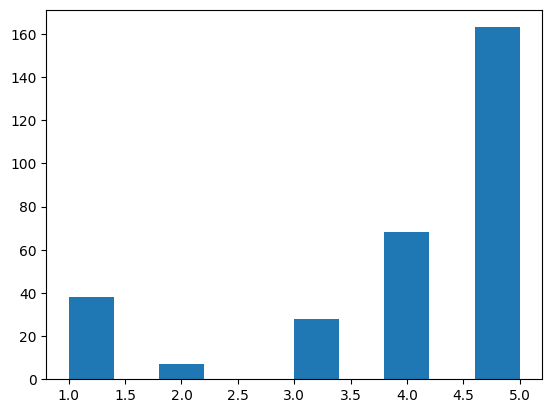

In [21]:
plt.hist(df["Rate"])
plt.show()


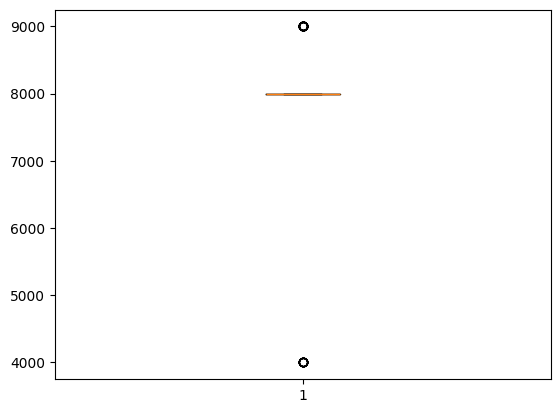

In [22]:
plt.boxplot(df["product_price"])
plt.show()

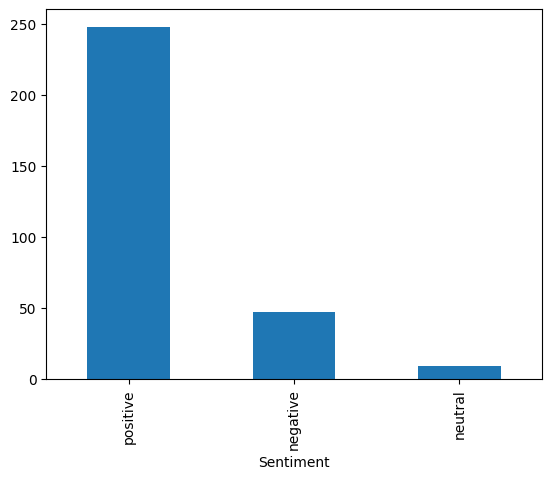

In [23]:
df["Sentiment"].value_counts().plot(kind="bar")
plt.show()

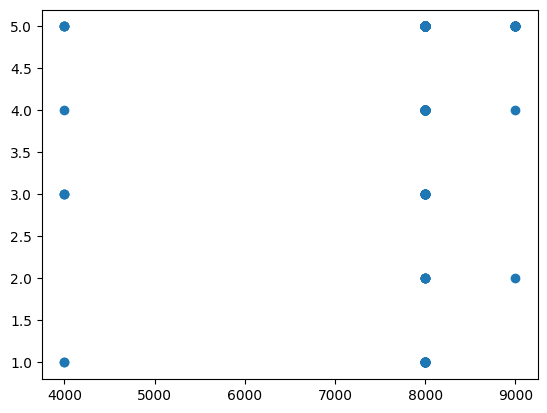

In [24]:
plt.scatter(df["product_price"], df["Rate"])
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB


In [26]:
X = df["Cleaned_Review"]
y = df["Sentiment"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
vectorizer = TfidfVectorizer()

In [29]:
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)


In [30]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score

In [33]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
lr_pred = lr.predict(X_test)


In [35]:
print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("LR Precision:", precision_score(y_test, lr_pred, average="weighted"))

LR Accuracy: 0.8852459016393442
LR Precision: 0.8685922456414259


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [37]:
knn_pred = knn.predict(X_test)

In [38]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("KNN Precision:", precision_score(y_test, knn_pred, average="weighted"))

KNN Accuracy: 0.8688524590163934
KNN Precision: 0.8475873801422826


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
from sklearn.metrics import classification_report, confusion_matrix

In [40]:
print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))

              precision    recall  f1-score   support

    negative       0.86      0.55      0.67        11
     neutral       0.00      0.00      0.00         1
    positive       0.89      0.98      0.93        49

    accuracy                           0.89        61
   macro avg       0.58      0.51      0.53        61
weighted avg       0.87      0.89      0.87        61

[[ 6  0  5]
 [ 0  0  1]
 [ 1  0 48]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
